Step1 完了：真の世界データ生成
    mu_true  sigma_true  S_true    D_true  default
0 -0.012569    0.215938       3  0.361417        1
1  0.049920    0.275555       3  0.434349        0
2  0.028489    0.143169       1  0.463230        0
3 -0.025189    0.232123       0  0.585045        1
4  0.002642    0.143606       2  0.445417        1

Step2 完了：代理変数生成
         mu     sigma  S         D  default
0 -0.029763  0.245158  3  0.284274        1
1  0.044507  0.288661  3  0.437198        0
2  0.020608  0.143237  1  0.519692        0
3 -0.022390  0.253174  0  0.536629        1
4  0.010115  0.154936  2  0.479641        1

Step3 完了：ロジット推定結果
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4995
Method:                           MLE   Df Model:                            4
Date:                Thu, 11 Jun 2026   Pseudo R-squ.:     

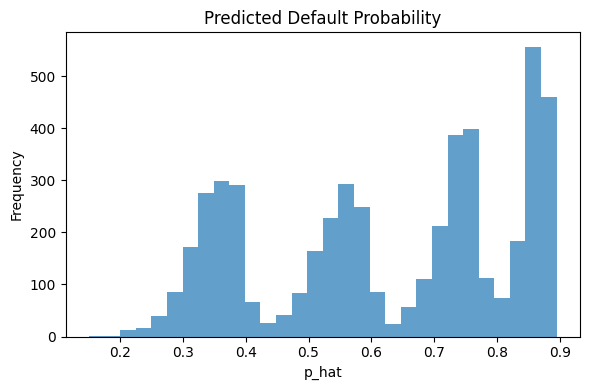

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

np.random.seed(123)

# ---------------------------------------------------------
# Step1：真の世界のデータ生成（CSV 不要）
# ---------------------------------------------------------

N = 5000

mu_true = np.random.normal(loc=0.02, scale=0.03, size=N)
sigma_true = np.random.normal(loc=0.20, scale=0.05, size=N)
S_true = np.random.choice([0,1,2,3], size=N, p=[0.25]*4)
D_true = np.random.lognormal(mean=-1.0, sigma=0.4, size=N)

a, b, c, d = 1.0, 1.0, 0.8, 1.2

Z_true = a*mu_true - b*sigma_true + c*S_true - d*D_true
p_true = 1 / (1 + np.exp(-Z_true))
default = np.random.binomial(n=1, p=p_true, size=N)

df_true = pd.DataFrame({
    "mu_true": mu_true,
    "sigma_true": sigma_true,
    "S_true": S_true,
    "D_true": D_true,
    "default": default
})

print("Step1 完了：真の世界データ生成")
print(df_true.head())

# ---------------------------------------------------------
# Step2：代理変数（proxy）生成（CSV 不要）
# ---------------------------------------------------------

mu_proxy = mu_true + np.random.normal(0, 0.01, size=N)
sigma_proxy = sigma_true + np.random.normal(0, 0.02, size=N)
S_proxy = S_true
D_proxy = D_true * np.exp(np.random.normal(0, 0.1, size=N))

df_proxy = pd.DataFrame({
    "mu": mu_proxy,
    "sigma": sigma_proxy,
    "S": S_proxy,
    "D": D_proxy,
    "default": default
})

print("\nStep2 完了：代理変数生成")
print(df_proxy.head())

# ---------------------------------------------------------
# Step3：ロジット推定（CSV 不要）
# ---------------------------------------------------------

X = df_proxy[["mu", "sigma", "S", "D"]]
X = sm.add_constant(X)
y = df_proxy["default"]

logit_model = sm.Logit(y, X)
result = logit_model.fit(disp=False)

print("\nStep3 完了：ロジット推定結果")
print(result.summary())

# ---------------------------------------------------------
# Step4：可視化（任意）
# ---------------------------------------------------------

plt.figure(figsize=(6,4))
plt.hist(result.predict(), bins=30, alpha=0.7)
plt.title("Predicted Default Probability")
plt.xlabel("p_hat")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()









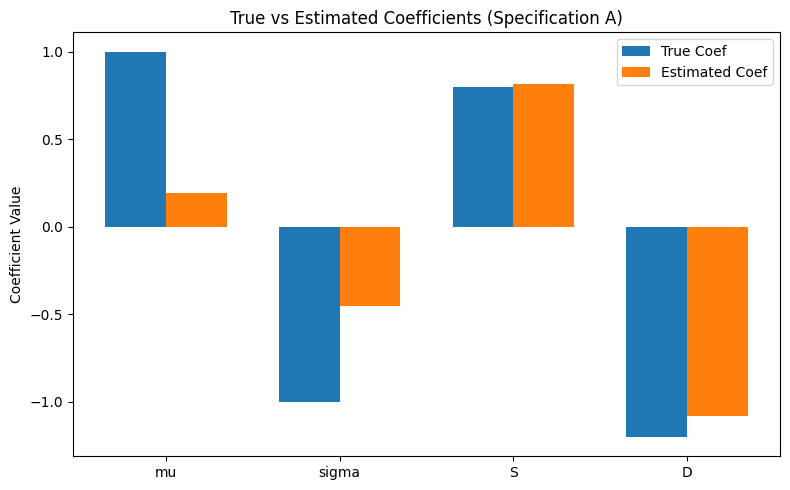

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 真の係数
true_coef = {
    "mu": 1.0,
    "sigma": -1.0,
    "S": 0.8,
    "D": -1.2
}

# 推定係数（Notebook 内の result を使用）
estimated_coef = {
    "mu": result.params["mu"],
    "sigma": result.params["sigma"],
    "S": result.params["S"],
    "D": result.params["D"]
}

labels = list(true_coef.keys())
true_vals = [true_coef[k] for k in labels]
est_vals = [estimated_coef[k] for k in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, true_vals, width, label="True Coef")
plt.bar(x + width/2, est_vals, width, label="Estimated Coef")

plt.xticks(x, labels)
plt.ylabel("Coefficient Value")
plt.title("True vs Estimated Coefficients (Specification A)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/coef_comparison.png", dpi=300)
plt.show()


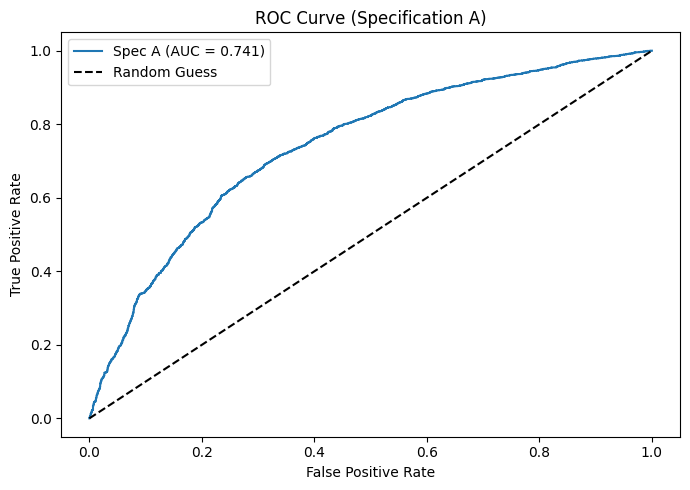

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_true = df_proxy["default"]
y_pred = result.predict()

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"Spec A (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Specification A)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/roc_comparison.png", dpi=300)
plt.show()


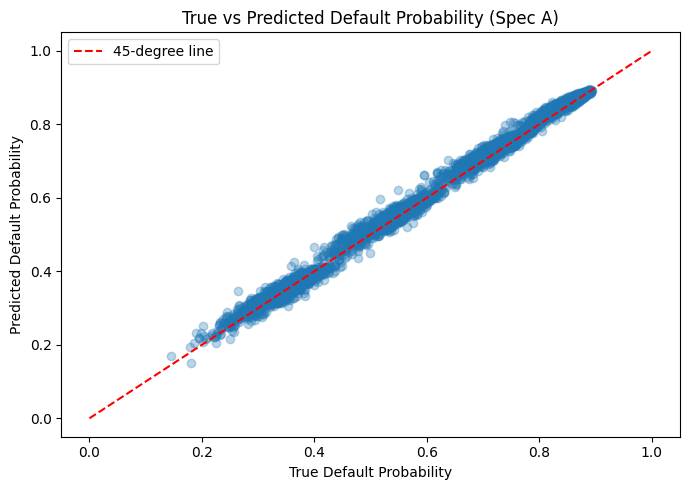

In [5]:
import matplotlib.pyplot as plt

p_pred = result.predict()

plt.figure(figsize=(7,5))
plt.scatter(p_true, p_pred, alpha=0.3)
plt.plot([0,1], [0,1], "r--", label="45-degree line")

plt.xlabel("True Default Probability")
plt.ylabel("Predicted Default Probability")
plt.title("True vs Predicted Default Probability (Spec A)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/scatter_true_vs_pred.png", dpi=300)
plt.show()
